# KNN & SVM — Distance-Based Models

**Goal:** Master the two most important instance-based and margin-based classifiers.

**Why it matters:**
- **KNN** — the simplest possible classifier. No training, just memory. A perfect teaching example for the bias-variance tradeoff.
- **SVM** — historically the strongest "shallow" classifier. Foundation for kernel methods and understanding margins.
- Both are **distance-based** → require careful feature scaling.
- Both are used in production when data is small/medium and interpretability is less critical.

**Prerequisite:** [02-tree-randomforest.ipynb](./02-tree-randomforest.ipynb)

**Dataset:** Titanic

---

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

print("Setup complete.")

Setup complete.


In [9]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["HasCabin"] = df["Cabin"].notna().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch",
         "Fare", "Embarked", "HasCabin", "FamilySize", "IsAlone"]]

X = df.drop(columns=["Survived"])
y = df["Survived"]

numeric_features = ["Age", "SibSp", "Parch", "Fare", "HasCabin", "FamilySize", "IsAlone"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 10), Test: (179, 10)


In [10]:


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None)),
    
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessor ready (with scaling).")

Preprocessor ready (with scaling).


## PART 1 — K-Nearest Neighbors (KNN)

### The Idea

**Training:** none. Just store the training data.  
**Prediction:** find the `k` nearest training points, take majority vote.

That's it. No parameters to learn, no gradient descent.

**Why it works:** Points close in feature space tend to have the same label.

### The Bias-Variance Tradeoff via `k`

| k | Behavior | Bias | Variance |
|---|----------|------|----------|
| 1 | Follows every point | Low | High (overfit) |
| 5–15 | Smooth decision boundary | Medium | Medium |
| Large | Over-smoothed | High (underfit) | Low |

### Key Hyperparameters

| Parameter | What it does | Options |
|-----------|-------------|---------|
| `n_neighbors` | How many neighbors vote | 1 to √n, tune it |
| `weights` | Uniform or distance-weighted | "uniform", "distance" |
| `metric` | Distance measure | "euclidean", "manhattan", "minkowski" |
| `p` | Minkowski power | 1=manhattan, 2=euclidean |
| `algorithm` | Search method | "auto", "ball_tree", "kd_tree", "brute" |

### Why Scaling is Non-Negotiable for KNN

If feature A ranges [0, 1000] and B ranges [0, 1], the distance is dominated by A.
Scaling forces every feature to contribute fairly.

---

In [11]:
knn_pipe = Pipeline([
  ("preprocessor", preprocessor),
  ("model", KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2,
    n_jobs= -1,

  )),


])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_proba_knn = knn_pipe.predict_proba(X_test)[:, 1]

print("=== KNN (k=5) ===")
print(f"Train accuracy: {knn_pipe.score(X_train, y_train):.4f}")
print(f"Test  accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba_knn):.4f}")
print(f"F1            : {f1_score(y_test, y_pred_knn):.4f}")


=== KNN (k=5) ===
Train accuracy: 0.8455
Test  accuracy: 0.7654
ROC-AUC       : 0.8318
F1            : 0.6957


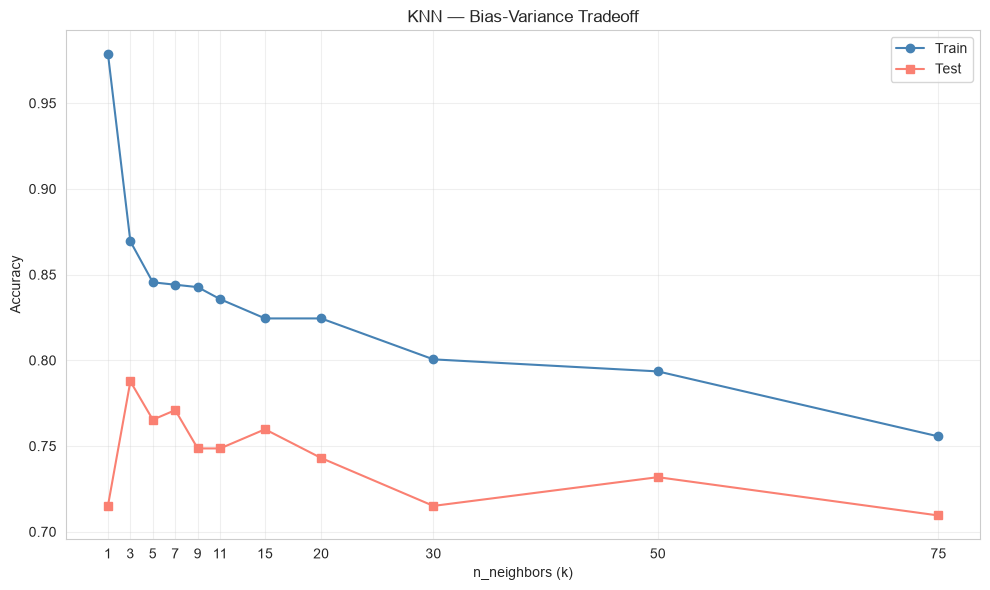

Best k by test accuracy: 3


In [12]:
# Sweep k values to see the bias-variance curve
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 30, 50, 75]
train_scores, test_scores = [], []

for k in k_values:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k, n_jobs=-1)),
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, "o-", label="Train", color="steelblue")
plt.plot(k_values, test_scores, "s-", label="Test", color="salmon")
plt.xlabel("n_neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN — Bias-Variance Tradeoff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(test_scores))]
print(f"Best k by test accuracy: {best_k}")

        # metric="minkowski" → generalized distance.
        #   "euclidean": straight-line distance (p=2)
        #   "manhattan": city-block distance (p=1)
        #   "minkowski": generic, controlled by `p`
        #   "cosine": for text/high-dim (direction, not magnitude)
        
        
        #   p=2 → Euclidean distance.
        #   p=1 → Manhattan
        #   p=3 → cubic
        #   Only matters when metric="minkowski".

In [13]:
for w in ["uniform", "distance"]:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=best_k, weights=w, n_jobs=-1)),
    ])
    pipe.fit(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)
    print(f"weights='{w}' → test accuracy = {test_acc:.4f}")

weights='uniform' → test accuracy = 0.7877
weights='distance' → test accuracy = 0.7933


## Support Vector Machine (SVM)

### The Idea

Find the **hyperplane** that separates classes with the **maximum margin**.

- **Margin**: distance between the hyperplane and nearest points of each class
- **Support vectors**: the training points that define the margin
- **Maximizing margin** → better generalization

### Handling Non-Linearity: The Kernel Trick

Real data isn't linearly separable. SVM uses **kernels** to project data into a higher-dimensional space where a hyperplane *can* separate it.

| Kernel | When to use |
|--------|-------------|
| `linear` | Data is (roughly) linearly separable; high-dim sparse data |
| `rbf` | General-purpose; most common for tabular data |
| `poly` | Rarely used in practice |
| `sigmoid` | Almost never used |

### Key Hyperparameters

| Parameter | Effect |
|-----------|--------|
| `C` | Regularization. Small C → wide margin, more errors (underfit). Large C → narrow margin (overfit). |
| `kernel` | `"linear"`, `"rbf"`, `"poly"`, `"sigmoid"` |
| `gamma` | RBF width. Small → smooth (underfit). Large → complex (overfit). |
| `class_weight` | Handle imbalance |

### Why SVM Needs Scaling

SVM depends on **inner products** and **distances**. Unscaled features break it exactly like KNN.

---

In [19]:
svm_linear = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        random_state=42,
    )),
])

svm_linear.fit(X_train, y_train)
y_pred_svmlin = svm_linear.predict(X_test)
y_proba_svmlin = svm_linear.predict_proba(X_test)[:, 1]

print("=== SVM (linear, C=1.0) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svmlin):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_svmlin):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_svmlin):.4f}")

c:\Users\Online\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM (linear, C=1.0) ===
Accuracy: 0.7933
ROC-AUC : 0.8209
F1      : 0.7132


In [ ]:

svm_rbf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42,
    )),
])

svm_rbf.fit(X_train, y_train)
y_pred_svmrbf = svm_rbf.predict(X_test)
y_proba_svmrbf = svm_rbf.predict_proba(X_test)[:, 1]

print("=== SVM (rbf, C=1.0, gamma='scale') ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svmrbf):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_svmrbf):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_svmrbf):.4f}")

c:\Users\Online\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM (rbf, C=1.0, gamma='scale') ===
Accuracy: 0.8324
ROC-AUC : 0.8406
F1      : 0.7656


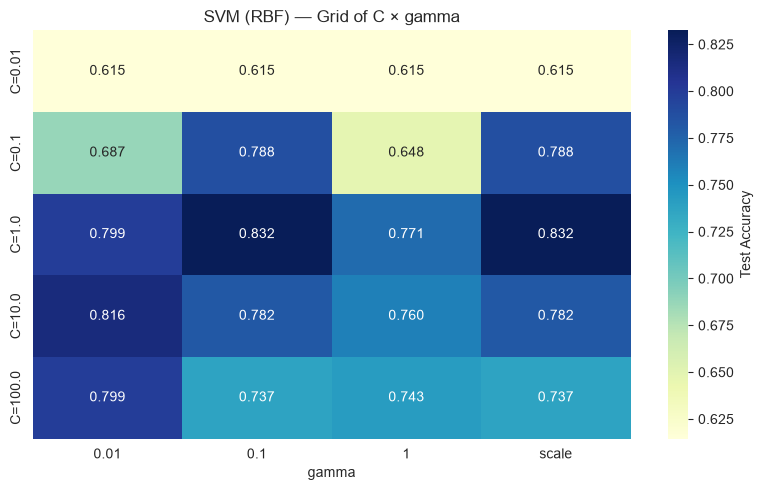

In [21]:
# Small grid to visualize sensitivity
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = ["scale", 0.01, 0.1, 1]

results = []
for C in C_values:
    for g in gamma_values:
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", SVC(kernel="rbf", C=C, gamma=g, random_state=42)),
        ])
        pipe.fit(X_train, y_train)
        results.append({"C": C, "gamma": g, "test_acc": pipe.score(X_test, y_test)})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index="C", columns="gamma", values="test_acc")
pivot.index = [f"C={c}" for c in pivot.index]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Test Accuracy"})
plt.title("SVM (RBF) — Grid of C × gamma")
plt.tight_layout()
plt.show()

In [22]:
knn_pipe_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_jobs=-1)),
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

knn_search = GridSearchCV(
    estimator=knn_pipe_full,
    param_grid=knn_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

knn_search.fit(X_train, y_train)

print(f"\nKNN best params: {knn_search.best_params_}")
print(f"KNN best CV ROC-AUC: {knn_search.best_score_:.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits

KNN best params: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'uniform'}
KNN best CV ROC-AUC: 0.8594


In [23]:
svm_pipe_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42)),
])

svm_grid = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1],
    
}

svm_search = GridSearchCV(
    estimator=svm_pipe_full,
    param_grid=svm_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

svm_search.fit(X_train, y_train)

print(f"\nSVM best params: {svm_search.best_params_}")
print(f"SVM best CV ROC-AUC: {svm_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

SVM best params: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
SVM best CV ROC-AUC: 0.8650


c:\Users\Online\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [24]:
best_knn = knn_search.best_estimator_
best_svm = svm_search.best_estimator_

print("=== Tuned KNN ===")
y_pred_knn_best = best_knn.predict(X_test)
y_proba_knn_best = best_knn.predict_proba(X_test)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn_best):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_knn_best):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_knn_best):.4f}")

print("\n=== Tuned SVM ===")
y_pred_svm_best = best_svm.predict(X_test)
y_proba_svm_best = best_svm.predict_proba(X_test)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_best):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_svm_best):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_svm_best):.4f}")

=== Tuned KNN ===
Accuracy: 0.7598
ROC-AUC : 0.8130
F1      : 0.6667

=== Tuned SVM ===
Accuracy: 0.7989
ROC-AUC : 0.8389
F1      : 0.7188


In [25]:
# Baselines from previous notebooks — same preprocessor for fair comparison
logreg = Pipeline([("preprocessor", preprocessor),
                   ("model", LogisticRegression(max_iter=1000, random_state=42))]).fit(X_train, y_train)

rf = Pipeline([("preprocessor", preprocessor),
               ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]).fit(X_train, y_train)

models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "KNN (tuned)": best_knn,
    "SVM (tuned)": best_svm,
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

leaderboard = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
print(leaderboard.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.8156     0.8000  0.6957 0.7442   0.8423
        SVM (tuned)    0.7989     0.7797  0.6667 0.7188   0.8389
      Random Forest    0.7877     0.7460  0.6812 0.7121   0.8292
        KNN (tuned)    0.7598     0.7167  0.6232 0.6667   0.8130


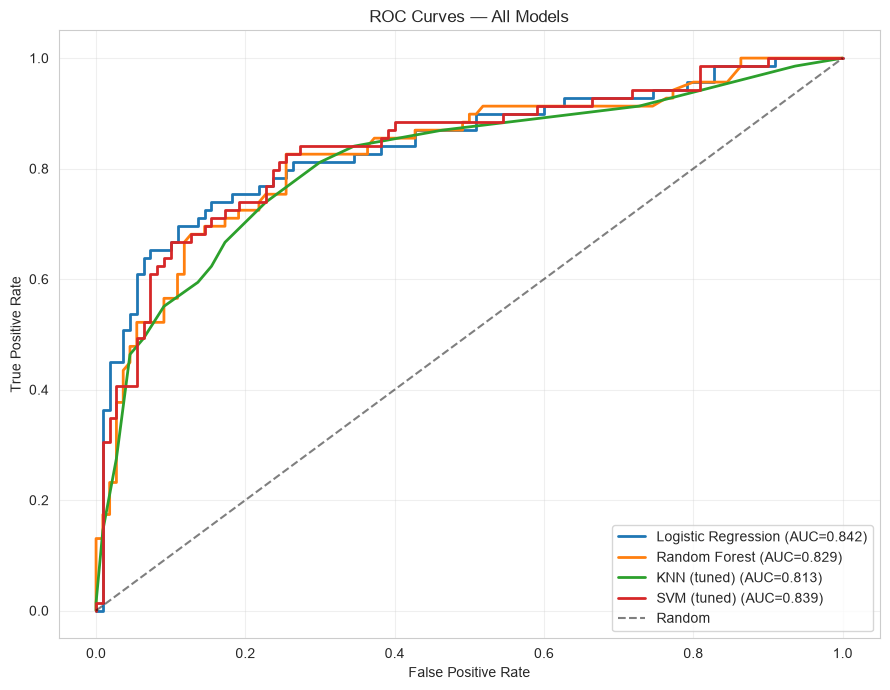

In [26]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

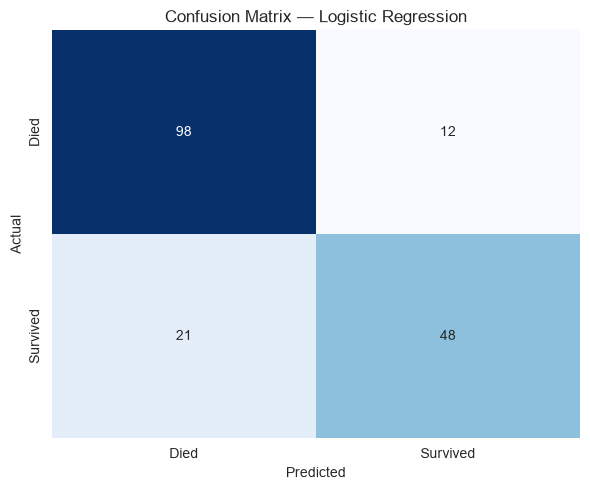

              precision    recall  f1-score   support

        Died       0.82      0.89      0.86       110
    Survived       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [27]:
best_name = leaderboard.iloc[0]["Model"]
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d",
    # annot=True → display the number inside each cell
    # fmt="d"    → integer format (not scientific like "1.2e+02")
    #              options: "d" (int), ".2f" (2 decimals), ".1%" (percent)
    
    cmap="Blues",
    # cmap → color palette.
    #   - Sequential: "Blues", "Reds", "Greens", "viridis", "YlGnBu"
    #   - Diverging: "coolwarm", "RdBu" (good for centered data)
    #   - Qualitative: "Set1", "tab10" (for categories)
    
    xticklabels=["Died", "Survived"],
    yticklabels=["Died", "Survived"],
    cbar=False,
    # cbar=False → hide the colorbar (redundant for a 2×2 confusion matrix)
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Died", "Survived"]))

## Summary

### KNN
- **No training** — lazy learner, just stores data
- **Non-parametric** — makes no assumption about data shape
- **Scaling is mandatory** — distances break otherwise
- **Slow prediction** on big data (O(n) per query with brute force)
- **Sensitive to irrelevant features** — they add noise to distances
- Tune `n_neighbors`, `weights`, `p`

### SVM
- **Margin maximization** — geometric intuition, strong theory
- **Kernel trick** — handles non-linear data without explicit projection
- **Scaling is mandatory** — inner products break otherwise
- **Slow training** on large data (O(n²) to O(n³))
- **Memory heavy** — stores support vectors (subset of training)
- Tune `C`, `kernel`, `gamma`

### Rule of Thumb

| Data size | Preferred |
|-----------|-----------|
| Small (<10K) | SVM (rbf), KNN |
| Medium (10K–1M) | Random Forest, Gradient Boosting |
| Large (>1M) | Gradient Boosting, Neural Nets |
| High-dim sparse (text) | Linear SVM, Logistic Regression |

### The Bigger Picture

We've now seen **four different inductive biases**:

| Model | Bias |
|-------|------|
| Logistic Regression | Linear in features |
| Decision Tree | Axis-aligned rectangular splits |
| Random Forest | Ensemble of rectangular splits |
| KNN | Local, instance-based |
| SVM (rbf) | Smooth non-linear boundaries |

**No single model wins everywhere.** This is the **No Free Lunch Theorem**.

## 🚀 Next

→ [04-xgboost-lightgbm.ipynb](./04-xgboost-lightgbm.ipynb): gradient boosting — the current state-of-the-art on tabular data.